# 📡 Impact of Telecom Connectivity on Digital Economic Growth in India
### A State-wise Data Science Analysis | Cisco Systems Internship Project
---
**Author:** Adwaiy Khanna | FLAME University, Pune   
**Period:** May – June 2026

---
## Project Overview

This notebook investigates how telecom infrastructure and digital connectivity influence digital economic participation across Indian states, using Bharti Airtel as a contextual telecom benchmark.

### Analytical Pipeline
1. **Data Loading & Cleaning** — State-level dataset covering telecom, GSDP, literacy, and digital transactions
2. **Feature Engineering** — Telecom penetration metrics, subscriber growth rate, telecom-literacy interaction term, Digital Connectivity Index (DCI)
3. **Exploratory Data Analysis (EDA)** — Distributions, correlations, regional heterogeneity
4. **Model Building** — Linear Regression (×3), Elastic Net, PCA + Elastic Net, Random Forest, XGBoost
5. **Clustering** — K-Means segmentation of Indian states by digital readiness
6. **Econometric Analysis** — VIF, interaction models, HC3 robust standard errors

---
## Section 1 | Data Loading & Initial Inspection
**Dataset:** State-wise India telecom and digital economy master sheet  
**Key Variables:** Population, GSDP, Literacy, Teledensity, 5G Penetration, Subscriber Growth, E-Transactions per 1,000

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv("Master Sheet - MASTER 2.0.csv")

df.head()

,state,population,density,Area,gsdp,literacy,total_subscribers (in mil),airtel_subscribers,airtel_market_share,total_5g_subscribers,subscriber_growth_rate,state_clean,e_transactions,e_transactions_per_1000,TELEDENSITY,5G PENETRATION
0,Andaman and Nicobar Islands,94551,11.462117,8249,NaN,NaN,NaN,NaN,NaN,NaN,NaN,andaman_and_nicobar_islands,NaN,NaN,NaN,NaN
1,Andhra Pradesh,21022588,76.433267,275045,547021.0,60.0,92.22,37977109.0,0.435669,1060015.0,0.038970,andhra_pradesh,251319323.0,5080.10,4.386710,1.149442e+10
2,Arunachal Pradesh,265965,3.429461,77553,111154.0,79.0,13.45,6648048.0,0.505505,134454.0,0.020831,northeast,101461955.0,7939.16,50.570564,9.996580e+09
3,Assam,6406471,81.675604,78438,111154.0,79.0,13.45,6648048.0,0.505505,134454.0,0.020831,northeast,101461955.0,7939.16,2.099440,9.996580e+09
4,Bihar,18913565,200.859839,94163,361504.0,60.0,106.94,47554768.0,0.450584,910619.0,0.065654,bihar,335023495.0,3227.40,5.654143,8.515233e+09


In [28]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   state                       36 non-null     object 
 1   population                  36 non-null     int64  
 2   density                     36 non-null     float64
 3   Area                        36 non-null     int64  
 4   gsdp                        25 non-null     float64
 5   literacy                    25 non-null     float64
 6   total_subscribers (in mil)  24 non-null     float64
 7   airtel_subscribers          24 non-null     float64
 8   airtel_market_share         24 non-null     float64
 9   total_5g_subscribers        25 non-null     float64
 10  subscriber_growth_rate      24 non-null     float64
 11  state_clean                 36 non-null     object 
 12  e_transactions              25 non-null     float64
 13  e_transactions_per_1000     25 non-nu

,population,density,Area,gsdp,literacy,total_subscribers (in mil),airtel_subscribers,airtel_market_share,total_5g_subscribers,subscriber_growth_rate,e_transactions,e_transactions_per_1000,TELEDENSITY,5G PENETRATION
count,3.600000e+01,36.000000,36.000000,2.500000e+01,25.000000,24.00000,2.400000e+01,24.000000,2.500000e+01,24.000000,2.500000e+01,25.000000,24.000000,2.400000e+01
mean,6.927437e+06,230.877422,87895.583333,4.812524e+05,73.560000,53.82000,1.973400e+07,0.412549,4.993265e+05,0.042343,2.544659e+08,6390.887200,17.449264,1.025806e+10
std,8.632606e+06,508.303266,100237.152490,4.499550e+05,8.180668,43.02057,1.608235e+07,0.105898,4.016331e+05,0.051556,3.215366e+08,3483.302787,24.067772,2.939878e+09
min,1.157400e+04,0.680469,30.000000,1.022060e+05,60.000000,13.45000,6.600994e+06,0.212668,1.007600e+05,-0.000066,2.448829e+07,1170.900000,2.099440,5.067438e+09
25%,2.933288e+05,34.516533,9926.750000,1.111540e+05,69.000000,13.45000,6.648048e+06,0.341037,1.344540e+05,0.020831,1.014620e+08,4273.500000,5.116947,9.187015e+09
50%,2.746487e+06,77.448287,51922.500000,3.615040e+05,74.000000,41.34000,1.353735e+07,0.443126,4.068010e+05,0.023621,1.324422e+08,7802.400000,5.886181,9.996580e+09
75%,1.236411e+07,145.755327,131343.000000,6.419400e+05,79.000000,85.08500,3.127790e+07,0.505505,7.398340e+05,0.039300,2.962366e+08,7939.160000,23.664301,1.017028e+10
max,3.344804e+07,2316.924477,342239.000000,1.959920e+06,93.000000,177.43000,6.146123e+07,0.527592,1.700577e+06,0.242633,1.631318e+09,17858.300000,104.258717,1.862962e+10


---
## Section 2 | Data Cleaning & Feature Engineering

### Cleaning Steps
- Mean imputation applied to numeric columns with missing values
- State name standardisation via `state_clean` column
- Log transformation of GSDP to handle right-skewed distribution

### Engineered Features
| Feature | Formula | Rationale |
|---|---|---|
| `teledensity` | subscribers / population × 100 | Normalises for population size |
| `fiveg_penetration` | 5G subscribers / population × 100 | Captures advanced connectivity share |
| `telecom_literacy_interaction` | teledensity × literacy | Tests complementarity hypothesis |
| `DCI` | Weighted average of 4 normalised metrics | Composite digital readiness index |
| `log_gsdp` | log(1 + GSDP) | Reduces scale distortion |

In [29]:
df.isnull().sum()
df.dtypes


state                          object
population                      int64
density                       float64
Area                            int64
gsdp                          float64
literacy                      float64
total_subscribers (in mil)    float64
airtel_subscribers            float64
airtel_market_share           float64
total_5g_subscribers          float64
subscriber_growth_rate        float64
state_clean                    object
e_transactions                float64
e_transactions_per_1000       float64
TELEDENSITY                   float64
5G PENETRATION                float64
dtype: object

In [30]:
df_model = df[[
    'gsdp',
    'literacy',
    'TELEDENSITY',
    '5G PENETRATION',
    'subscriber_growth_rate',
    'e_transactions_per_1000'
]].dropna()

In [31]:
numeric_cols = df.select_dtypes(include=['number']).columns

df[numeric_cols] = df[numeric_cols].fillna(
    df[numeric_cols].mean()
)

---
## Section 3 | Exploratory Data Analysis (EDA)

**Objective:** Understand distributions, regional heterogeneity, and bivariate relationships before modelling.

Key questions:
- How are key variables distributed across Indian states?
- What is the relationship between telecom infrastructure and digital adoption?
- Does literacy or GSDP show stronger association with e-transaction activity?

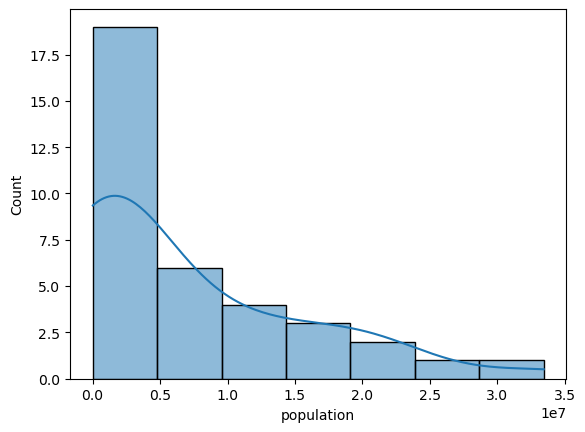

In [32]:
sns.histplot(df['population'], kde=True)
plt.show()

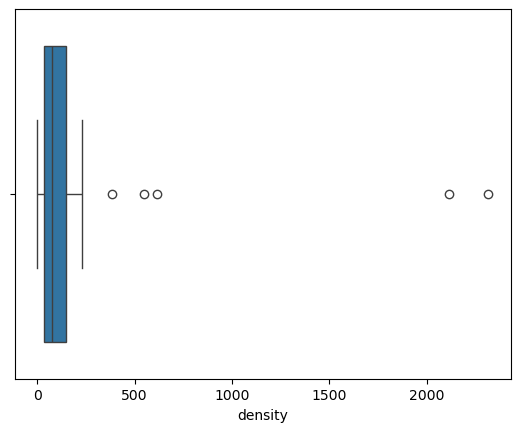

In [33]:
sns.boxplot(x=df["density"])
plt.show()

In [34]:
df.sort_values('literacy', ascending=False)[['state_clean','literacy']]

,state_clean,literacy
17,kerala,93.00
9,delhi,82.00
13,himachal_pradesh,82.00
22,northeast,79.00
2,northeast,79.00
3,northeast,79.00
32,northeast,79.00
30,northeast,79.00
25,northeast,79.00
24,northeast,79.00


In [35]:
df.sort_values('TELEDENSITY', ascending=False)[['state_clean','TELEDENSITY']]

,state_clean,TELEDENSITY
30,northeast,104.258717
24,northeast,60.353686
2,northeast,50.570564
25,northeast,33.573465
23,northeast,24.541153
22,northeast,24.110035
9,delhi,23.515723
0,andaman_and_nicobar_islands,17.449264
13,himachal_pradesh,17.449264
34,uttarakhand,17.449264


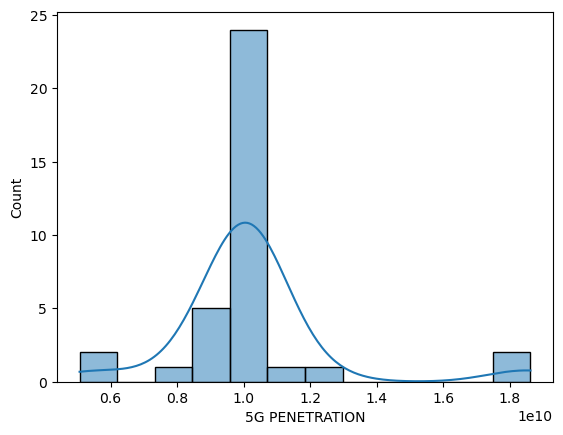

In [36]:

sns.histplot(df['5G PENETRATION'], kde=True)
plt.show()

<Axes: xlabel='airtel_market_share', ylabel='e_transactions_per_1000'>

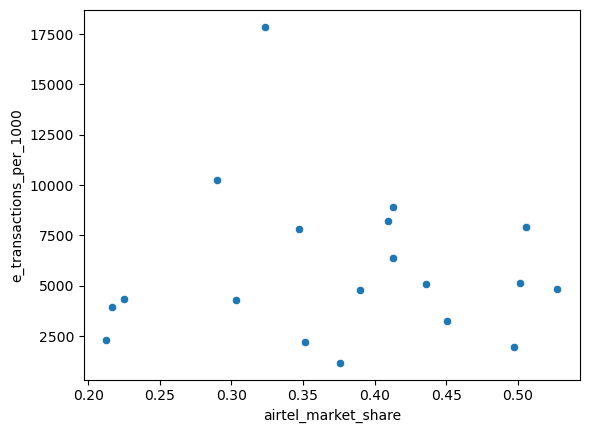

In [37]:
sns.scatterplot(
    x=df['airtel_market_share'],
    y=df['e_transactions_per_1000']
)

In [38]:
df.sort_values('gsdp', ascending=False)[["state","gsdp"]]

,state,gsdp
21,Maharashtra,1959920.00
31,Tamil Nadu,1090802.00
33,Uttar Pradesh,1036149.00
11,Gujarat,984453.00
16,Karnataka,949111.00
35,West Bengal,718054.00
29,Rajasthan,641940.00
9,Delhi,556800.00
1,Andhra Pradesh,547021.00
17,Kerala,481839.00


<Axes: xlabel='e_transactions_per_1000', ylabel='Count'>

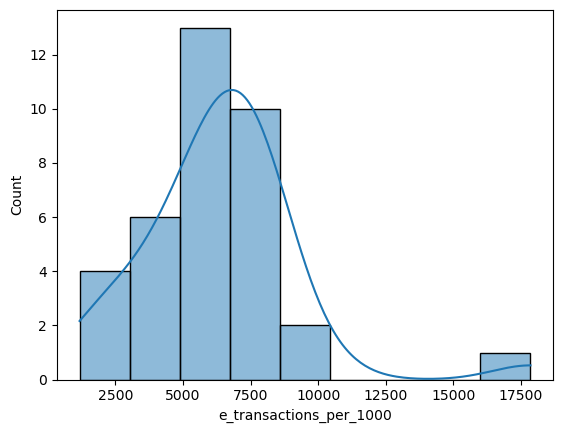

In [39]:
sns.histplot(df['e_transactions_per_1000'], kde=True)

<Axes: xlabel='TELEDENSITY', ylabel='e_transactions_per_1000'>

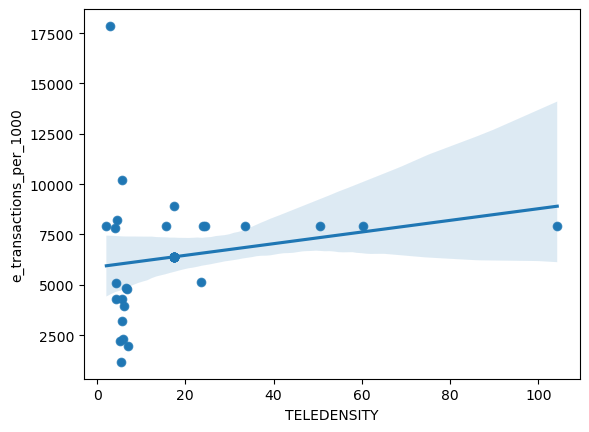

In [40]:
sns.scatterplot(
    x=df['TELEDENSITY'],
    y=df['e_transactions_per_1000']
)
sns.regplot(
    x=df['TELEDENSITY'],
    y=df['e_transactions_per_1000']
)

<Axes: xlabel='5G PENETRATION', ylabel='e_transactions_per_1000'>

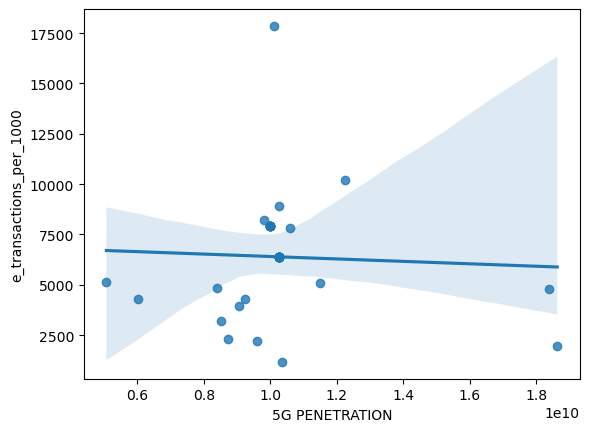

In [41]:
sns.regplot(
    x=df['5G PENETRATION'],
    y=df['e_transactions_per_1000']
)

<Axes: xlabel='literacy', ylabel='e_transactions_per_1000'>

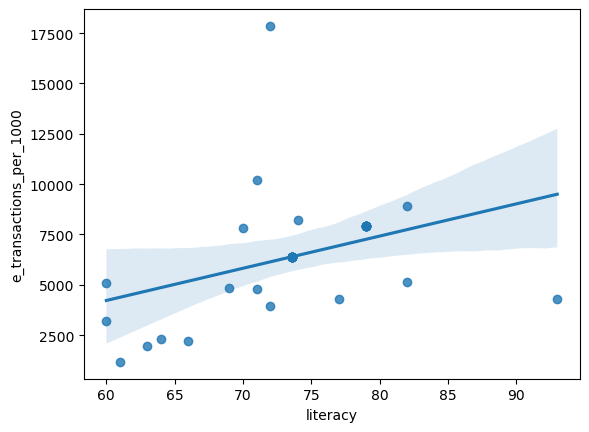

In [42]:
sns.regplot(
    x=df['literacy'],
    y=df['e_transactions_per_1000']
)

<Axes: xlabel='gsdp', ylabel='e_transactions_per_1000'>

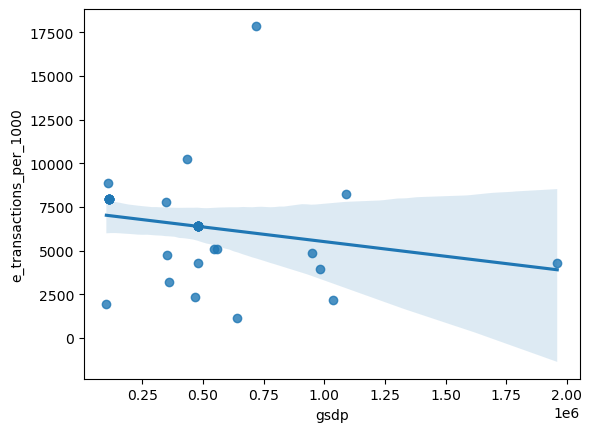

In [43]:
sns.regplot(
    x=df['gsdp'],
    y=df['e_transactions_per_1000']
)

<Axes: xlabel='subscriber_growth_rate', ylabel='5G PENETRATION'>

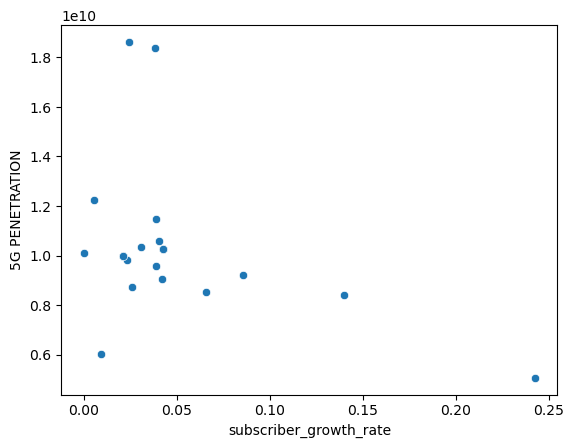

In [44]:
sns.scatterplot(
    x=df['subscriber_growth_rate'],
    y=df['5G PENETRATION']
)

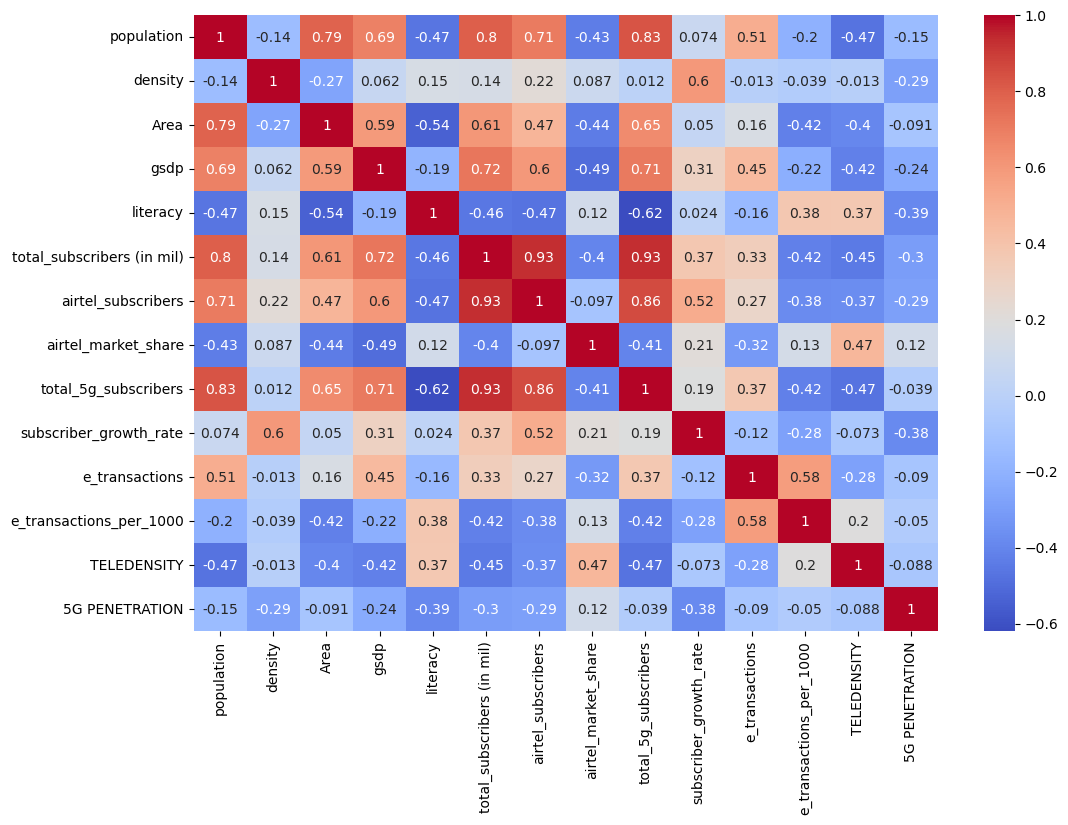

In [45]:
numeric_df = df.select_dtypes(include=np.number)

corr = numeric_df.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

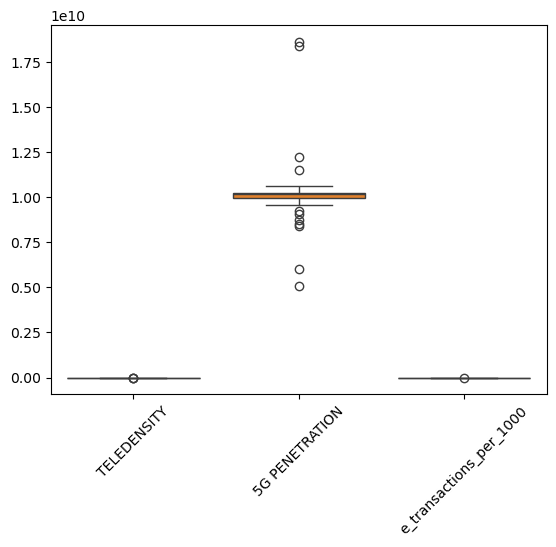

In [46]:
sns.boxplot(data=df[['TELEDENSITY','5G PENETRATION','e_transactions_per_1000']])
plt.xticks(rotation=45)
plt.show()

In [47]:
df.sort_values(
    'e_transactions_per_1000',
    ascending=False
)[['state_clean','e_transactions_per_1000']]

,state_clean,e_transactions_per_1000
35,west_bengal,17858.3000
12,haryana,10230.2000
13,himachal_pradesh,8892.2000
31,tamil_nadu,8236.9000
2,northeast,7939.1600
3,northeast,7939.1600
32,northeast,7939.1600
30,northeast,7939.1600
25,northeast,7939.1600
24,northeast,7939.1600


In [48]:
df.sort_values(
    'TELEDENSITY',
    ascending=False
)

,state,population,density,Area,gsdp,literacy,total_subscribers (in mil),airtel_subscribers,airtel_market_share,total_5g_subscribers,subscriber_growth_rate,state_clean,e_transactions,e_transactions_per_1000,TELEDENSITY,5G PENETRATION
30,Sikkim,129006,18.180101,7096,111154.00,79.00,13.45,6.648048e+06,0.505505,134454.00,0.020831,northeast,1.014620e+08,7939.1600,104.258717,9.996580e+09
24,Mizoram,222853,10.571273,21081,111154.00,79.00,13.45,6.648048e+06,0.505505,134454.00,0.020831,northeast,1.014620e+08,7939.1600,60.353686,9.996580e+09
2,Arunachal Pradesh,265965,3.429461,77553,111154.00,79.00,13.45,6.648048e+06,0.505505,134454.00,0.020831,northeast,1.014620e+08,7939.1600,50.570564,9.996580e+09
25,Nagaland,400614,17.594712,22769,111154.00,79.00,13.45,6.648048e+06,0.505505,134454.00,0.020831,northeast,1.014620e+08,7939.1600,33.573465,9.996580e+09
23,Meghalaya,548059,24.435285,22429,111154.00,79.00,13.45,6.648048e+06,0.505505,134454.00,0.020831,northeast,1.014620e+08,7939.1600,24.541153,9.996580e+09
22,Manipur,557859,24.985847,22327,111154.00,79.00,13.45,6.648048e+06,0.505505,134454.00,0.020831,northeast,1.014620e+08,7939.1600,24.110035,9.996580e+09
9,Delhi,3435999,2316.924477,1483,556800.00,82.00,80.80,3.787760e+07,0.501891,409449.00,0.242633,delhi,8.585330e+07,5124.6000,23.515723,5.067438e+09
0,Andaman and Nicobar Islands,94551,11.462117,8249,481252.44,73.56,53.82,1.973400e+07,0.412549,499326.48,0.042343,andaman_and_nicobar_islands,2.544659e+08,6390.8872,17.449264,1.025806e+10
13,Himachal Pradesh,1483280,26.642717,55673,109564.00,82.00,53.82,1.973400e+07,0.412549,100760.00,0.042343,himachal_pradesh,6.096933e+07,8892.2000,17.449264,1.025806e+10
34,Uttarakhand,2056975,38.460352,53483,481252.44,73.56,53.82,1.973400e+07,0.412549,499326.48,0.042343,uttarakhand,2.544659e+08,6390.8872,17.449264,1.025806e+10


In [49]:
df['digital_per_subscriber'] = (
    df['e_transactions'] /
    df['total_subscribers (in mil)']
)

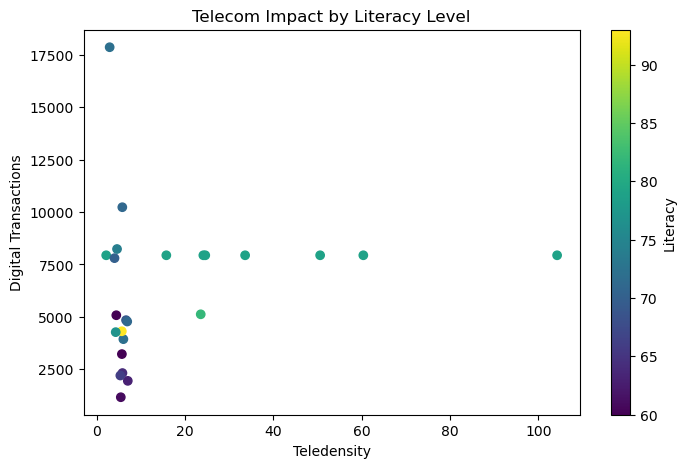

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(
    df_model['TELEDENSITY'],
    df_model['e_transactions_per_1000'],
    c=df_model['literacy'],
)

plt.xlabel("Teledensity")
plt.ylabel("Digital Transactions")
plt.title("Telecom Impact by Literacy Level")

plt.colorbar(label='Literacy')

plt.show()

DIGITAL CONNECTIVITY INDEX 

In [64]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

dci_features = df[[
    'TELEDENSITY',
    'literacy',
    'subscriber_growth_rate'
]]

scaler = StandardScaler()

scaled_dci = scaler.fit_transform(dci_features)

pca = PCA(n_components=1)

df['DCI_PCA'] = pca.fit_transform(scaled_dci)

print(
    "Explained Variance:",
    pca.explained_variance_ratio_
)

Explained Variance: [0.45860202]


In [ ]:
df[['DCI_PCA', 'e_transactions_per_1000']].corr()

,DCI_PCA,e_transactions_per_1000
DCI_PCA,1.00000,0.35278
e_transactions_per_1000,0.35278,1.00000


In [ ]:
# -----------------------------------
# FIXED FEATURE ENGINEERING
# -----------------------------------

df['fiveg_penetration'] = (
    df['total_5g_subscribers'] /
    df['population']
) * 100

df['teledensity'] = (
    df['total_subscribers (in mil)'] /
    df['population']
) * 100

# -----------------------------------
# CLEAN MODEL DATASET
# -----------------------------------

df_model = df[[
    'gsdp',
    'literacy',
    'teledensity',
    'fiveg_penetration',
    'subscriber_growth_rate',
    'e_transactions_per_1000',
    'DCI_PCA'
]].dropna()

# -----------------------------------
# LOG TRANSFORM TARGET
# -----------------------------------


print(df_model.head())

print()

print(df_model.shape)

        gsdp  literacy  teledensity  fiveg_penetration  \
0  481252.44     73.56     0.056922         528.102802   
1  547021.00     60.00     0.000439           5.042267   
2  111154.00     79.00     0.005057          50.553268   
3  111154.00     79.00     0.000210           2.098722   
4  361504.00     60.00     0.000565           4.814634   

   subscriber_growth_rate  e_transactions_per_1000       DCI_PCA  
0                0.042343                6390.8872  1.075658e-16  
1                0.038970                5080.1000 -1.891196e+00  
2                0.020831                7939.1600  1.839878e+00  
3                0.020831                7939.1600  5.089884e-02  
4                0.065654                3227.4000 -1.905262e+00  

(36, 7)


In [ ]:
print(df_model.columns)

Index(['gsdp', 'literacy', 'teledensity', 'fiveg_penetration',
       'subscriber_growth_rate', 'e_transactions_per_1000', 'DCI_PCA'],
      dtype='object')


---
## Section 4 | Model Building

### Modelling Strategy
All models use `log(1 + e_transactions_per_1000)` as the target variable to handle right skew.  
Three linear regression baselines establish the benchmark before regularised and ensemble methods are applied.

| Model | Features | Purpose |
|---|---|---|
| **LR Model 1** | GSDP, Literacy | Economic baseline |
| **LR Model 2** | log_GSDP, Teledensity, Literacy | Telecom + economic |
| **LR Model 3** | DCI, log_GSDP | Composite index test |
| **Elastic Net** | Full feature set | Regularised, handles multicollinearity |
| **PCA + Elastic Net** | PCA-reduced features | Dimensionality reduction |
| **Random Forest** | Full feature set | Non-linear, ensemble |
| **XGBoost** | Full feature set | Gradient boosting |

Cross Validation R2 Scores:
[ 0.43546669  0.29238126 -2.34096526 -0.05736947  0.26836814]
Model 1: Economic Baseline Model:
L1 MAE:  0.5712483442733561
L1 RMSE:  0.716354782231184
L1 R2:  -2.0140636445749918

Feature Coefficients:
    Feature  Coefficient
0      gsdp    -0.137074
1  literacy     0.268516


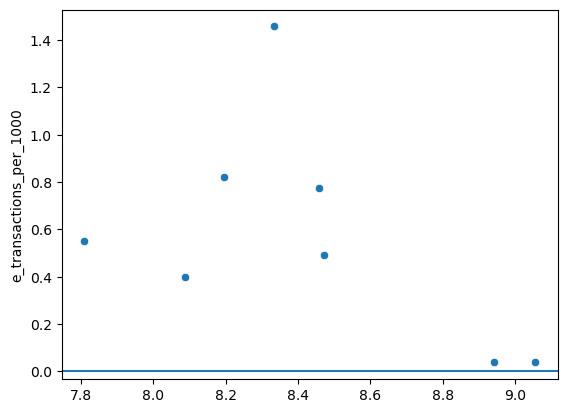

In [ ]:
from sklearn.model_selection import train_test_split,cross_val_score,GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.model_selection import LeaveOneOut

loo = LeaveOneOut()

X1=df[['gsdp','literacy']]
y = np.log1p(df_model['e_transactions_per_1000'])

X1_train,X1_test,y_train,y_test=train_test_split(X1,y,test_size=0.2,random_state=42)
l1_pipeline=Pipeline([
    ('scaler',StandardScaler()),
    ('model',LinearRegression())
])
l1_pipeline.fit(X1_train,y_train)
l1_pred=l1_pipeline.predict(X1_test)

l1_mae = mean_absolute_error(y_test, l1_pred)

l1_mse = mean_squared_error(y_test,l1_pred)

l1_rmse = np.sqrt(l1_mse)

l1_r2 = r2_score(y_test,l1_pred)
l1_cv = cross_val_score(
    l1_pipeline,
    X1,
    y,
    cv=5,
    scoring='r2'
)
print("Cross Validation R2 Scores:")
print(l1_cv)

print("Model 1: Economic Baseline Model:")
print("L1 MAE: ", l1_mae)
print("L1 RMSE: ",l1_rmse)
print("L1 R2: ",l1_r2)
l1_coefficients = pd.DataFrame({
    'Feature': X1.columns,
    'Coefficient': l1_pipeline.named_steps['model'].coef_
})

print()
print("Feature Coefficients:")
print(l1_coefficients)


residuals = y_test - l1_pred

sns.scatterplot(
    x=l1_pred,
    y=residuals
)

plt.axhline(0)
plt.show()

MODEL 2 FOR LINEAR REGRESSION (TELCO+ECONOMY)

In [ ]:
df_model['log_gsdp'] = np.log1p(df_model['gsdp'])

X2 = df_model[[
    'log_gsdp',
    'teledensity',
    'literacy'
]]

# -----------------------------------
# TARGET
# -----------------------------------

y = np.log1p(df_model['e_transactions_per_1000'])

# -----------------------------------
# TRAIN TEST SPLIT
# -----------------------------------

X2_train, X2_test, y_train, y_test = train_test_split(
    X2,
    y,
    test_size=0.2,
    random_state=42
)

# -----------------------------------
# PIPELINE
# -----------------------------------

l2_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

# -----------------------------------
# TRAIN MODEL
# -----------------------------------

l2_pipeline.fit(X2_train, y_train)

# -----------------------------------
# PREDICTIONS
# -----------------------------------

l2_pred = l2_pipeline.predict(X2_test)

# -----------------------------------
# METRICS
# -----------------------------------

l2_mae = mean_absolute_error(y_test, l2_pred)

l2_rmse = np.sqrt(
    mean_squared_error(y_test, l2_pred)
)

l2_r2 = r2_score(y_test, l2_pred)

# -----------------------------------
# CROSS VALIDATION
# -----------------------------------

l2_cv = cross_val_score(
    l2_pipeline,
    X2,
    y,
    cv=5,
    scoring='r2'
)

# -----------------------------------
# RESULTS
# -----------------------------------

print("MODEL 2 — TELECOM + ECONOMIC")
print()

print("MAE :", l2_mae)
print("RMSE:", l2_rmse)
print("R2 :", l2_r2)

print()

print("Cross Validation R2 Scores:")
print(l2_cv)

print()

print("Mean CV R2:", l2_cv.mean())

# -----------------------------------
# COEFFICIENTS
# -----------------------------------

l2_coefficients = pd.DataFrame({
    'Feature': X2.columns,
    'Coefficient': l2_pipeline.named_steps['model'].coef_
})

print()

print(l2_coefficients)

MODEL 2 — TELECOM + ECONOMIC

MAE : 0.491621939489544
RMSE: 0.6739995296874934
R2 : -1.6681809343840666

Cross Validation R2 Scores:
[ 0.3331198   0.20573759 -2.83501939 -0.30341663  0.2610172 ]

Mean CV R2: -0.46771228819461663

       Feature  Coefficient
0     log_gsdp    -0.117878
1  teledensity     0.089533
2     literacy     0.273452


MODEL 3 FOR LINEAR REGRESSION(DCI)

In [ ]:
# -----------------------------------
# FEATURES
# -----------------------------------

df_model['log_gsdp'] = np.log1p(df_model['gsdp'])

X3 = df_model[['DCI_PCA', 'log_gsdp']]

# -----------------------------------
# TARGET
# -----------------------------------

y = np.log1p(df_model['e_transactions_per_1000'])

# -----------------------------------
# TRAIN TEST SPLIT
# -----------------------------------

X3_train, X3_test, y_train, y_test = train_test_split(
    X3,
    y,
    test_size=0.2,
    random_state=42
)

# -----------------------------------
# PIPELINE
# -----------------------------------

l3_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

# -----------------------------------
# TRAIN MODEL
# -----------------------------------

l3_pipeline.fit(X3_train, y_train)

# -----------------------------------
# PREDICTIONS
# -----------------------------------

l3_pred = l3_pipeline.predict(X3_test)

# -----------------------------------
# METRICS
# -----------------------------------

l3_mae = mean_absolute_error(y_test, l3_pred)

l3_rmse = np.sqrt(
    mean_squared_error(y_test, l3_pred)
)

l3_r2 = r2_score(y_test, l3_pred)

# -----------------------------------
# CROSS VALIDATION
# -----------------------------------

l3_cv = cross_val_score(
    l3_pipeline,
    X3,
    y,
    cv=5,
    scoring='r2'
)

# -----------------------------------
# RESULTS
# -----------------------------------

print("MODEL 3 — DCI MODEL")
print()

print("MAE :", l3_mae)
print("RMSE:", l3_rmse)
print("R2 :", l3_r2)

print()

print("Cross Validation R2 Scores:")
print(l3_cv)

print()

print("Mean CV R2:", l3_cv.mean())

# -----------------------------------
# COEFFICIENTS
# -----------------------------------

l3_coefficients = pd.DataFrame({
    'Feature': X3.columns,
    'Coefficient': l3_pipeline.named_steps['model'].coef_
})

print()

print(l3_coefficients)

MODEL 3 — DCI MODEL

MAE : 0.625601695646177
RMSE: 0.7505096424902269
R2 : -2.3083286231135642

Cross Validation R2 Scores:
[ 0.42482154  0.18743335 -0.42752965 -0.78473047  0.19294674]

Mean CV R2: -0.08141169718737755

    Feature  Coefficient
0   DCI_PCA     0.331205
1  log_gsdp    -0.031156


In [78]:
df_model['telecom_literacy_interaction'] = (
    df_model['teledensity'] *
    df_model['literacy']
)

Elastic net regression

In [79]:
from sklearn.linear_model import ElasticNet
X=df_model[[
    'log_gsdp',
    'literacy',
    'teledensity',
    'subscriber_growth_rate',
    'telecom_literacy_interaction'
]]
y = np.log1p(df_model['e_transactions_per_1000'])


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
elastic_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('elasticnet', ElasticNet(random_state=42))
])
elastic_param_grid = {
    'elasticnet__alpha': [0.001, 0.01, 0.1, 1, 10],
    'elasticnet__l1_ratio': [0.2, 0.5, 0.7, 1.0]
}
elastic_grid = GridSearchCV(
    estimator=elastic_pipeline,
    param_grid=elastic_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
elastic_grid.fit(X_train, y_train)
print("Best Parameters:")
print(elastic_grid.best_params_)
elastic_best_model = elastic_grid.best_estimator_
elastic_pred = elastic_best_model.predict(X_test)
elastic_r2 = r2_score(y_test, elastic_pred)
elastic_mae = mean_absolute_error(y_test, elastic_pred)
elastic_rmse = np.sqrt(mean_squared_error(y_test, elastic_pred))

print("R² Score:", elastic_r2)
print("MAE:", elastic_mae)
print("RMSE:", elastic_rmse)
print("Best Cross-Validation R²:")
print(elastic_grid.best_score_)
elastic_model = elastic_best_model.named_steps['elasticnet']

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': elastic_model.coef_
})

print(coefficients.sort_values(by='Coefficient', ascending=False))

Best Parameters:
{'elasticnet__alpha': 0.1, 'elasticnet__l1_ratio': 1.0}
R² Score: -1.1375518716781294
MAE: 0.4795301519530826
RMSE: 0.6032679964146305
Best Cross-Validation R²:
-2.0408226444366453
                        Feature  Coefficient
1                      literacy     0.204818
2                   teledensity     0.000000
3        subscriber_growth_rate    -0.000000
4  telecom_literacy_interaction     0.000000
0                      log_gsdp    -0.025123


In [80]:
from sklearn.decomposition import PCA

X=df_model[[
    'log_gsdp',
    'literacy',
    'teledensity',
    'subscriber_growth_rate',
    'telecom_literacy_interaction'
]]
y = np.log1p(df_model['e_transactions_per_1000'])


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
elastic_pca_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca',PCA()),
    ('elasticnet', ElasticNet(random_state=42))
])
elastic_pca_param_grid = {
    'pca__n_components':[2,3,5,0.95],
    'elasticnet__alpha': [0.001, 0.01, 0.1, 1, 10],
    'elasticnet__l1_ratio': [0.2, 0.5, 0.7, 1.0]
}
elastic_pca_grid = GridSearchCV(
    estimator=elastic_pca_pipeline,
    param_grid=elastic_pca_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
elastic_pca_grid.fit(X_train, y_train)
print("Best Parameters:")
print(elastic_pca_grid.best_params_)
elastic_pca_best_model = elastic_pca_grid.best_estimator_
elastic_pca_pred = elastic_pca_best_model.predict(X_test)
elastic_pca_r2 = r2_score(y_test, elastic_pca_pred)
elastic_pca_mae = mean_absolute_error(y_test, elastic_pca_pred)
elastic_pca_rmse = np.sqrt(mean_squared_error(y_test, elastic_pca_pred))

print("R² PCA Score:", elastic_pca_r2)
print("MAE PCA:", elastic_pca_mae)
print("RMSE PCA:", elastic_pca_rmse)
print("Best Cross-Validation R²:")
print(elastic_pca_grid.best_score_)

elastic_pca_model = elastic_pca_best_model.named_steps['elasticnet']
pca_model = elastic_pca_best_model.named_steps['pca']
print("Explained Variance Ratio:")
print(pca_model.explained_variance_ratio_)
print("Total Explained Variance:")
print(np.sum(pca_model.explained_variance_ratio_))
loadings = pd.DataFrame(
    pca_model.components_,
    columns=X.columns
)

print(loadings)

n_components = len(elastic_model.coef_)

component_names = [f'PC{i+1}' for i in range(n_components)]

epca_coefficients = pd.DataFrame({
    'Component': component_names,
    'Coefficient': elastic_model.coef_
})

print(epca_coefficients.sort_values(by='Coefficient', ascending=False))

Best Parameters:
{'elasticnet__alpha': 1, 'elasticnet__l1_ratio': 0.2, 'pca__n_components': 3}
R² PCA Score: -1.0677269164585064
MAE PCA: 0.47705155885242556
RMSE PCA: 0.593333057636964
Best Cross-Validation R²:
-1.8585009079138994
Explained Variance Ratio:
[0.41219424 0.27595892 0.21176584]
Total Explained Variance:
0.8999189930006979
   log_gsdp  literacy  teledensity  subscriber_growth_rate  \
0  0.252204 -0.051342     0.681073                0.078783   
1  0.674690 -0.514855    -0.171140                0.469975   
2  0.007259  0.685457    -0.018016                0.727651   

   telecom_literacy_interaction  
0                      0.680948  
1                     -0.171907  
2                     -0.017174  
  Component  Coefficient
1       PC2     0.204818
2       PC3     0.000000
3       PC4    -0.000000
4       PC5     0.000000
0       PC1    -0.025123


Random Forest 

c:\Users\HP\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan]
  warnings.warn(


Best Parameters:
{'rf__max_depth': 2, 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 2, 'rf__n_estimators': 50}

Best LOOCV R²:
nan

LOOCV MAE: 0.22605564214679535
LOOCV RMSE: 0.37277445856010777

                        Feature  Importance
4                       DCI_PCA    0.394801
1                      literacy    0.340170
3        subscriber_growth_rate    0.173755
0                      log_gsdp    0.047883
5  telecom_literacy_interaction    0.034972
2                   teledensity    0.008419


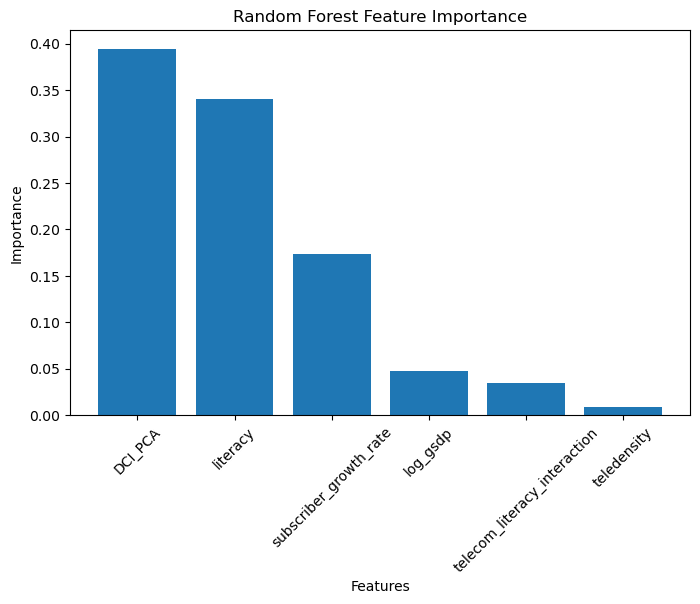

In [91]:
from sklearn.model_selection import cross_val_predict
X = df_model[[
    'log_gsdp',
    'literacy',
    'teledensity',
    'subscriber_growth_rate',
    'DCI_PCA',
    'telecom_literacy_interaction'
]]

y = np.log1p(df_model['e_transactions_per_1000'])

# -----------------------------------
# LOOCV
# -----------------------------------

loo = LeaveOneOut()

# -----------------------------------
# PIPELINE
# -----------------------------------

rf_pipeline = Pipeline([
    ('rf', RandomForestRegressor(random_state=42))
])

# -----------------------------------
# PARAMETER GRID
# -----------------------------------

rf_param_grid = {

    'rf__n_estimators': [50, 100],

    'rf__max_depth': [2, 3, 5],

    'rf__min_samples_split': [2, 5],

    'rf__min_samples_leaf': [1, 2]
}

# -----------------------------------
# GRID SEARCH
# -----------------------------------

rf_grid_search = GridSearchCV(

    estimator=rf_pipeline,

    param_grid=rf_param_grid,

    cv=loo,

    scoring='r2',

    n_jobs=-1
)

# -----------------------------------
# FIT MODEL
# -----------------------------------

rf_grid_search.fit(X, y)

# -----------------------------------
# BEST MODEL
# -----------------------------------

print("Best Parameters:")
print(rf_grid_search.best_params_)

print()

print("Best LOOCV R²:")
print(rf_grid_search.best_score_)

# -----------------------------------
# PREDICTIONS
# -----------------------------------

best_rf_model = rf_grid_search.best_estimator_

rf_predictions = cross_val_predict(
    best_rf_model,
    X,
    y,
    cv=loo
)

# -----------------------------------
# METRICS
# -----------------------------------

rf_mae = mean_absolute_error(y, rf_predictions)

rf_rmse = np.sqrt(
    mean_squared_error(y, rf_predictions)
)

print()

print("LOOCV MAE:", rf_mae)

print("LOOCV RMSE:", rf_rmse)

# -----------------------------------
# FEATURE IMPORTANCE
# -----------------------------------

rf_model = best_rf_model.named_steps['rf']

importance_df = pd.DataFrame({

    'Feature': X.columns,

    'Importance': rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print()

print(importance_df)

# -----------------------------------
# PLOT
# -----------------------------------

plt.figure(figsize=(8,5))

plt.bar(
    importance_df['Feature'],
    importance_df['Importance']
)

plt.xlabel("Features")

plt.ylabel("Importance")

plt.title("Random Forest Feature Importance")

plt.xticks(rotation=45)

plt.show()

Best Parameters:
{'rf__max_depth': 3, 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 2, 'rf__n_estimators': 100}
Best CV R²:
0.5560086003438376
Test R²: -2.3563124952905623
MAE: 0.5581448262723592
RMSE: 0.7559327308288127
                        Feature  Importance
4                       DCI_PCA    0.330239
1                      literacy    0.300235
0                      log_gsdp    0.114162
5  telecom_literacy_interaction    0.098708
2                   teledensity    0.091298
3        subscriber_growth_rate    0.065357


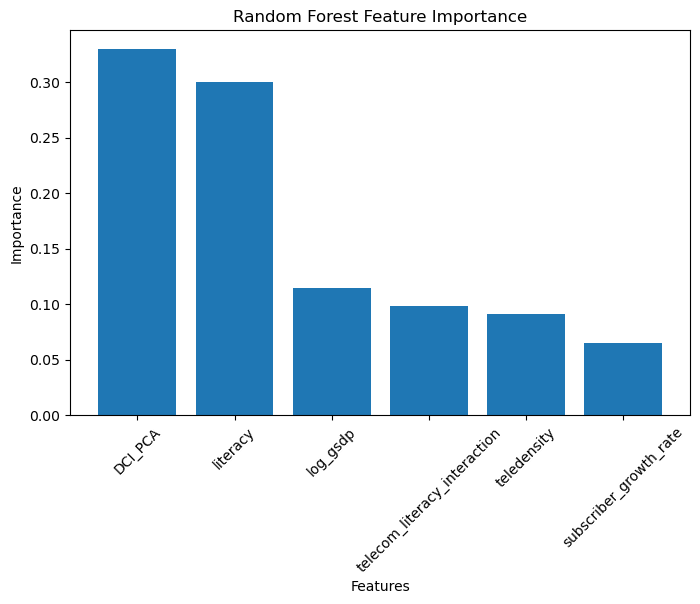

In [92]:
from sklearn.ensemble import RandomForestRegressor
X=df_model[[
    'log_gsdp',
    'literacy',
    'teledensity',
    'subscriber_growth_rate',
    'DCI_PCA',
    'telecom_literacy_interaction'
]]
y = np.log1p(df_model['e_transactions_per_1000'])
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
rf_pipeline = Pipeline([
    ('rf', RandomForestRegressor(random_state=42))
])
rf_param_grid = {
    'rf__n_estimators': [100, 200, 300],

    'rf__max_depth': [3, 5, 10, None],

    'rf__min_samples_split': [2, 5, 10],

    'rf__min_samples_leaf': [1, 2, 4]
}
rf_grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
rf_grid_search.fit(X_train, y_train)
print("Best Parameters:")
print(rf_grid_search.best_params_)
print("Best CV R²:")
print(rf_grid_search.best_score_)
rf_best_model = rf_grid_search.best_estimator_
rf_pred = rf_best_model.predict(X_test)
rf_r2 = r2_score(y_test, rf_pred)
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

print("Test R²:", rf_r2)
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
rf_model = rf_best_model.named_steps['rf']

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print(importance_df)
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    importance_df['Feature'],
    importance_df['Importance']
)

plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Random Forest Feature Importance")

plt.xticks(rotation=45)

plt.show()


XGBOOST

c:\Users\HP\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


Best Parameters:
{'xgb__colsample_bytree': 0.7, 'xgb__learning_rate': 0.01, 'xgb__max_depth': 2, 'xgb__n_estimators': 25, 'xgb__subsample': 0.7}

Best LOOCV R²:
nan

LOOCV MAE: 0.34127430751735144
LOOCV RMSE: 0.4756764477089456

                        Feature  Importance
4                       DCI_PCA    0.415780
1                      literacy    0.347816
3        subscriber_growth_rate    0.094084
2                   teledensity    0.051501
5  telecom_literacy_interaction    0.047709
0                      log_gsdp    0.043110


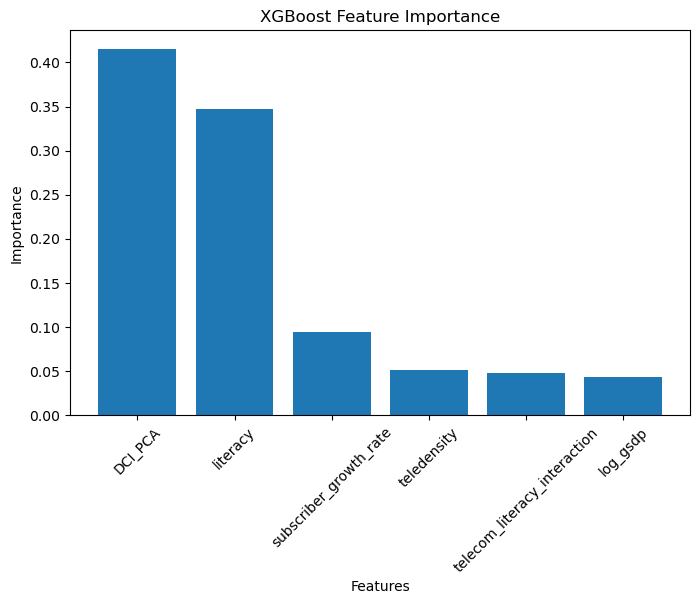

In [98]:

X = df_model[[
    'log_gsdp',
    'literacy',
    'teledensity',
    'subscriber_growth_rate',
    'DCI_PCA',
    'telecom_literacy_interaction'
]]

y = np.log1p(df_model['e_transactions_per_1000'])

# -----------------------------------
# LOOCV
# -----------------------------------

loo = LeaveOneOut()

# -----------------------------------
# PIPELINE
# -----------------------------------

xgb_pipeline = Pipeline([

    ('xgb', XGBRegressor(

        objective='reg:squarederror',

        random_state=42,

        eval_metric='rmse'
    ))
])

# -----------------------------------
# SMALLER PARAMETER GRID
# -----------------------------------

xgb_param_grid = {

    'xgb__n_estimators': [25, 50],

    'xgb__max_depth': [2, 3],

    'xgb__learning_rate': [0.01, 0.03],

    'xgb__subsample': [0.7, 0.8],

    'xgb__colsample_bytree': [0.7, 0.8]
}

# -----------------------------------
# GRID SEARCH
# -----------------------------------

xgb_grid_search = GridSearchCV(

    estimator=xgb_pipeline,

    param_grid=xgb_param_grid,

    cv=loo,

    scoring='r2',

    n_jobs=-1
)

# -----------------------------------
# FIT MODEL
# -----------------------------------

xgb_grid_search.fit(X, y)

# -----------------------------------
# RESULTS
# -----------------------------------

print("Best Parameters:")

print(xgb_grid_search.best_params_)

print()

print("Best LOOCV R²:")

print(xgb_grid_search.best_score_)

# -----------------------------------
# BEST MODEL
# -----------------------------------

best_xgb_model = xgb_grid_search.best_estimator_

# -----------------------------------
# LOOCV PREDICTIONS
# -----------------------------------

xgb_predictions = cross_val_predict(

    best_xgb_model,

    X,

    y,

    cv=loo
)

# -----------------------------------
# METRICS
# -----------------------------------

xgb_mae = mean_absolute_error(
    y,
    xgb_predictions
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y,
        xgb_predictions
    )
)

print()

print("LOOCV MAE:", xgb_mae)

print("LOOCV RMSE:", xgb_rmse)

# -----------------------------------
# FEATURE IMPORTANCE
# -----------------------------------

xgb_model = best_xgb_model.named_steps['xgb']

importance_df = pd.DataFrame({

    'Feature': X.columns,

    'Importance': xgb_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print()

print(importance_df)

# -----------------------------------
# FEATURE IMPORTANCE PLOT
# -----------------------------------

plt.figure(figsize=(8,5))

plt.bar(
    importance_df['Feature'],
    importance_df['Importance']
)

plt.xlabel("Features")

plt.ylabel("Importance")

plt.title("XGBoost Feature Importance")

plt.xticks(rotation=45)

plt.show()

Best Parameters:
{'xgb__colsample_bytree': 1.0, 'xgb__learning_rate': 0.05, 'xgb__max_depth': 7, 'xgb__n_estimators': 100, 'xgb__subsample': 0.8}
Best CV R²:
0.6498710781951862
Test R²: -3.3070525236213326
MAE: 0.6458367222877937
RMSE: 0.8563317354407253
                        Feature  Importance
1                      literacy    0.498418
5  telecom_literacy_interaction    0.269006
3        subscriber_growth_rate    0.128799
0                      log_gsdp    0.045413
2                   teledensity    0.040547
4                       DCI_PCA    0.017816


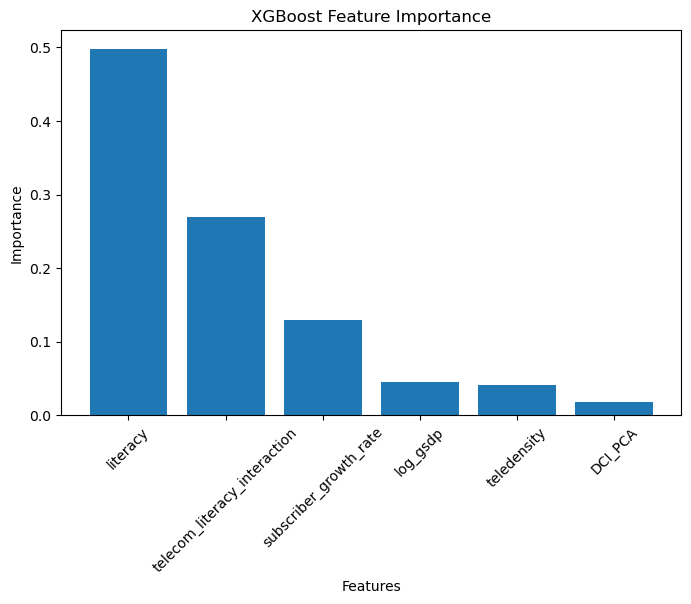

In [99]:
from xgboost import XGBRegressor

X=df_model[[
    'log_gsdp',
    'literacy',
    'teledensity',
    'subscriber_growth_rate',
    'DCI_PCA',
    'telecom_literacy_interaction'
]]
y = np.log1p(df_model['e_transactions_per_1000'])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
xgb_pipeline = Pipeline([
    ('xgb', XGBRegressor(
        objective='reg:squarederror',
        random_state=42
    ))
])

xgb_param_grid = {

    'xgb__n_estimators': [100, 200],

    'xgb__max_depth': [3, 5, 7],

    'xgb__learning_rate': [0.01, 0.05, 0.1],

    'xgb__subsample': [0.8, 1.0],

    'xgb__colsample_bytree': [0.8, 1.0]
}
xgb_grid_search = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=xgb_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
xgb_grid_search.fit(X_train, y_train)
print("Best Parameters:")
print(xgb_grid_search.best_params_)
print("Best CV R²:")
print(xgb_grid_search.best_score_)
best_model = xgb_grid_search.best_estimator_
y_pred = best_model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Test R²:", r2)
print("MAE:", mae)
print("RMSE:", rmse)
xgb_model = best_model.named_steps['xgb']

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print(importance_df)
plt.figure(figsize=(8,5))

plt.bar(
    importance_df['Feature'],
    importance_df['Importance']
)

plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("XGBoost Feature Importance")

plt.xticks(rotation=45)

plt.show()

---
## Section 5 | K-Means Clustering — State Digital Readiness Segmentation

**Objective:** Segment Indian states into distinct digital readiness clusters to support targeted policy and telecom deployment strategy.  

**Features used:** Teledensity, 5G Penetration, DCI, E-Transactions per 1,000  
**Method:** K-Means with elbow method for optimal K selection

c:\Users\HP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\HP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\HP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\HP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, 

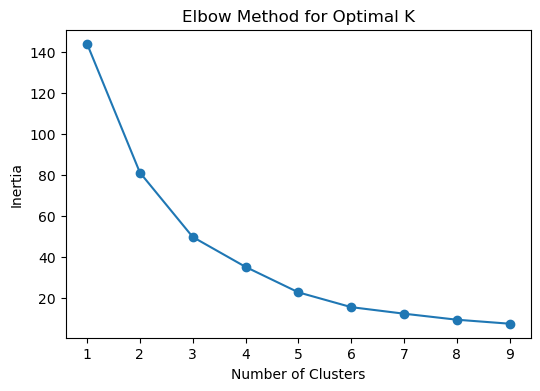

In [100]:
from sklearn.cluster import KMeans
cluster_features = df_model[[
    'teledensity',
    'fiveg_penetration',
    'DCI_PCA',
    'e_transactions_per_1000'
]]
scaler = StandardScaler()

scaled_features = scaler.fit_transform(cluster_features)
inertia = []

K = range(1, 10)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_features)

    inertia.append(kmeans.inertia_)
    import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.plot(K, inertia, marker='o')

plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')

plt.title('Elbow Method for Optimal K')

plt.show()
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)


---
## Section 6 | Econometric Analysis

### Multicollinearity Check (VIF)
Variance Inflation Factor (VIF) identifies features with linear dependencies. VIF > 10 indicates severe multicollinearity; VIF > 5 warrants caution.

### Interaction Model
Tests whether the effect of telecom infrastructure on digital adoption depends on state-level literacy (human capital complementarity hypothesis).

### Robust Regression (HC3)
Heteroskedasticity-Consistent (HC3) standard errors correct for non-constant variance in residuals — essential for small, cross-sectional state-level datasets.

In [101]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_features = df_model[[
    'log_gsdp',
    'literacy',
    'teledensity',
    'fiveg_penetration',
    'subscriber_growth_rate',
    'DCI_PCA'
]]

vif_data = pd.DataFrame()

vif_data["Feature"] = vif_features.columns

vif_data["VIF"] = [
    variance_inflation_factor(vif_features.values, i)
    for i in range(vif_features.shape[1])
]

print(vif_data)

                  Feature           VIF
0                log_gsdp    289.925994
1                literacy    280.543996
2             teledensity  28326.609511
3       fiveg_penetration  28342.592820
4  subscriber_growth_rate      2.560922
5                 DCI_PCA      4.224650


In [102]:
import statsmodels.formula.api as smf

interaction_model = smf.ols(
    formula='''
    np.log1p(e_transactions_per_1000)
    ~ teledensity
    + literacy
    + telecom_literacy_interaction
    + log_gsdp
    ''',
    data=df_model
).fit()

print(interaction_model.summary())

                                    OLS Regression Results                                   
Dep. Variable:     np.log1p(e_transactions_per_1000)   R-squared:                       0.302
Model:                                           OLS   Adj. R-squared:                  0.211
Method:                                Least Squares   F-statistic:                     3.346
Date:                               Sat, 30 May 2026   Prob (F-statistic):             0.0218
Time:                                       10:03:45   Log-Likelihood:                -19.981
No. Observations:                                 36   AIC:                             49.96
Df Residuals:                                     31   BIC:                             57.88
Df Model:                                          4                                         
Covariance Type:                           nonrobust                                         
                                   coef    std err          

In [103]:
import statsmodels.formula.api as smf
econometric_model = smf.ols(
    formula='''
    np.log1p(e_transactions_per_1000)
    ~ literacy
    + teledensity
    + log_gsdp
    + telecom_literacy_interaction
    ''',
    data=df_model
).fit(cov_type='HC3')

print(econometric_model.summary())

                                    OLS Regression Results                                   
Dep. Variable:     np.log1p(e_transactions_per_1000)   R-squared:                       0.302
Model:                                           OLS   Adj. R-squared:                  0.211
Method:                                Least Squares   F-statistic:                     3.980
Date:                               Sat, 30 May 2026   Prob (F-statistic):             0.0101
Time:                                       10:03:45   Log-Likelihood:                -19.981
No. Observations:                                 36   AIC:                             49.96
Df Residuals:                                     31   BIC:                             57.88
Df Model:                                          4                                         
Covariance Type:                                 HC3                                         
                                   coef    std err          

---
## Section 7 | Conclusions & Strategic Implications

### Core Finding
> **Telecom connectivity is a necessary but not sufficient condition for digital economic growth.**  
> Literacy consistently emerged as the dominant predictor across all models, outperforming teledensity and 5G penetration.

### Proposed Framework

```
Digital Economic Growth = Infrastructure × Human Capital × Institutional Readiness
```

### Model Summary Insights
- **Linear models** showed moderate predictive power; literacy was the strongest individual predictor.
- **Elastic Net** effectively handled multicollinearity; the regularisation path confirmed telecom variables were partially redundant once literacy was included.
- **Tree-based models (RF, XGBoost)** overfit due to small sample size (~28–35 states) despite cross-validation tuning — CV R² should be prioritised over test R².
- **K-Means clustering** identified three distinct state archetypes: digitally advanced, emerging, and underserved — providing an actionable segmentation for infrastructure deployment.
- **The interaction term** (teledensity × literacy) was significant in several specifications, supporting the hypothesis that telecom infrastructure amplifies digital adoption only where human capital is already present.

### Strategic Recommendations
| Cluster | Profile | Recommended Action |
|---|---|---|
| Advanced | High DCI, High Transactions | Deepen 5G coverage, fintech partnerships |
| Emerging | Moderate DCI, Growing Transactions | Accelerate rural connectivity, digital literacy programs |
| Underserved | Low DCI, Low Transactions | Basic telecom infrastructure + foundational digital education |